## import libraries

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

## read of data

In [93]:
import kagglehub

path = kagglehub.dataset_download("bumba5341/advertisingcsv")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'advertisingcsv' dataset.
Path to dataset files: /kaggle/input/advertisingcsv


In [94]:
df = pd.read_csv(path+"/Advertising.csv")

## processing of data

In [95]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [96]:
df.sample(5)

,Unnamed: 0,TV,Radio,Newspaper,Sales
83,84,68.4,44.5,35.6,13.6
163,164,163.5,36.8,7.4,18.0
147,148,243.2,49.0,44.3,25.4
102,103,280.2,10.1,21.4,14.8
167,168,206.8,5.2,19.4,12.2


In [97]:
df.tail()

,Unnamed: 0,TV,Radio,Newspaper,Sales
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5
199,200,232.1,8.6,8.7,13.4


In [98]:
df.rename(columns={'Unnamed: 0': 'Index'}, inplace=True)

In [99]:
df

,Index,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [100]:
df.isnull().sum()

,0
Index,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [101]:
df.duplicated().sum()

np.int64(0)

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Index      200 non-null    int64  
 1   TV         200 non-null    float64
 2   Radio      200 non-null    float64
 3   Newspaper  200 non-null    float64
 4   Sales      200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [103]:
df.shape

(200, 5)

In [104]:
df.describe()

,Index,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


## EDA

In [105]:
px.box(data_frame=df,x='TV')

In [106]:
px.box(data_frame=df,x='Radio')

<Axes: ylabel='Count'>

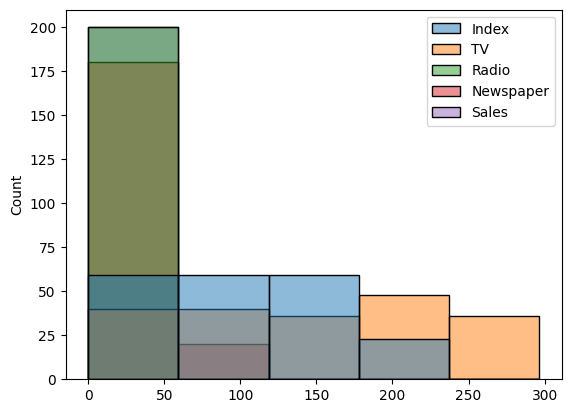

In [107]:
sns.histplot(data=df,bins=5)

array([[<Axes: title={'center': 'Index'}>,
        <Axes: title={'center': 'TV'}>],
       [<Axes: title={'center': 'Radio'}>,
        <Axes: title={'center': 'Newspaper'}>],
       [<Axes: title={'center': 'Sales'}>, <Axes: >]], dtype=object)

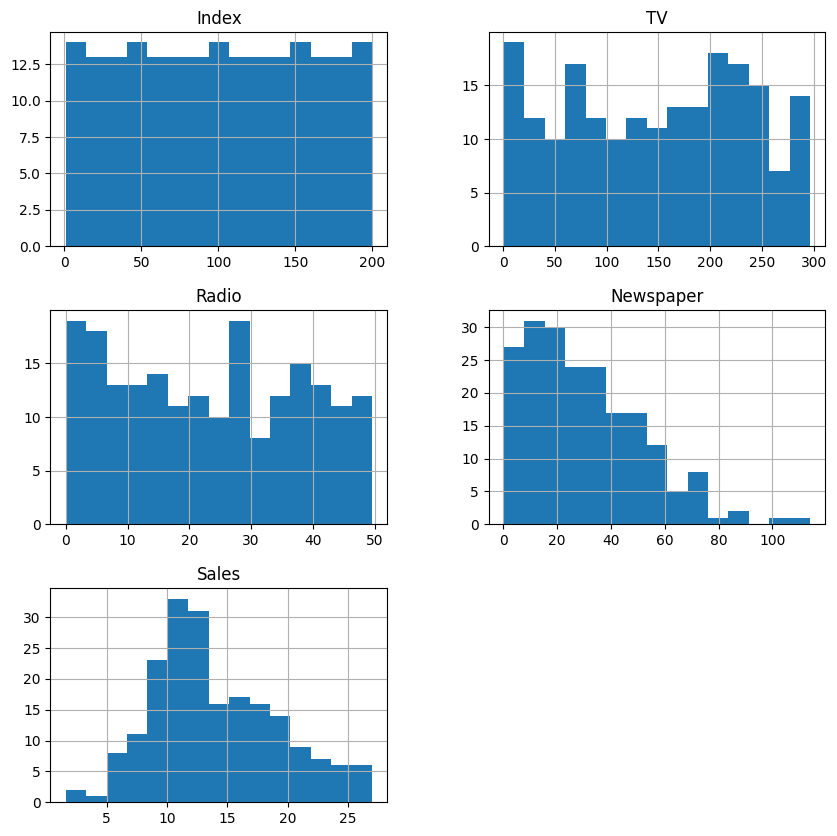

In [108]:
df.hist(bins=15,figsize=(10,10))

In [109]:
px.scatter(data_frame=df,x='TV',y='Sales')

In [110]:
px.scatter(data_frame=df,x='Radio',y='Sales')

<Axes: xlabel='Newspaper', ylabel='Sales'>

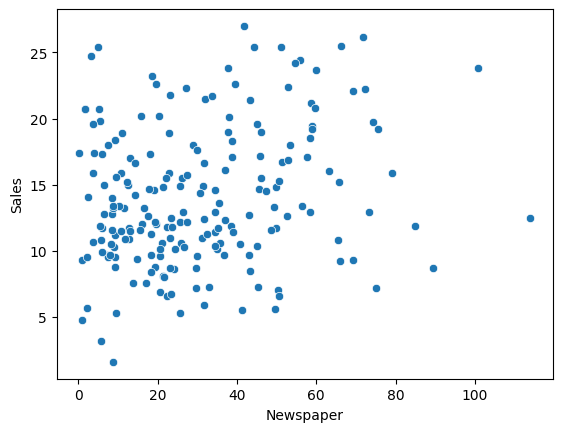

In [111]:
sns.scatterplot(data=df,x='Newspaper',y='Sales')

<Axes: xlabel='TV', ylabel='Sales'>

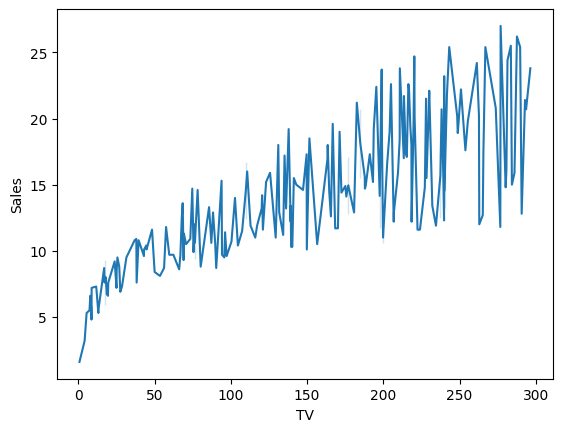

In [112]:
sns.lineplot(data=df,x='TV',y='Sales')

<Axes: xlabel='Radio', ylabel='Sales'>

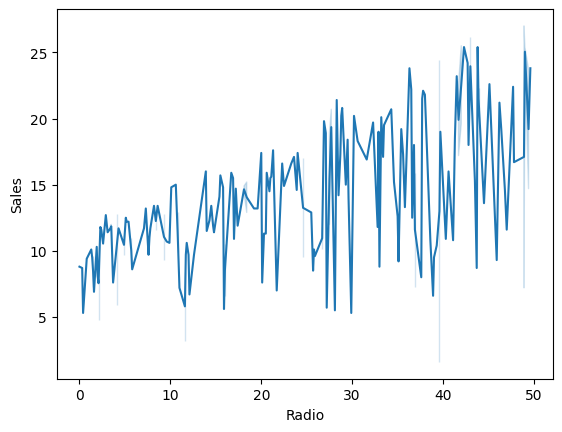

In [113]:
sns.lineplot(data=df,x='Radio',y='Sales')

<Axes: xlabel='Newspaper', ylabel='Sales'>

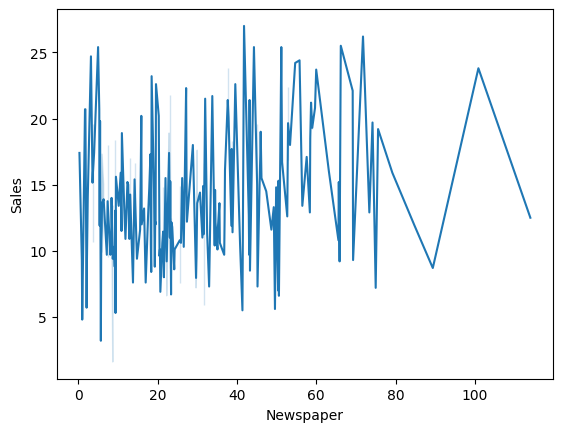

In [114]:
sns.lineplot(data=df,x='Newspaper',y='Sales')

<Axes: xlabel='TV', ylabel='Sales'>

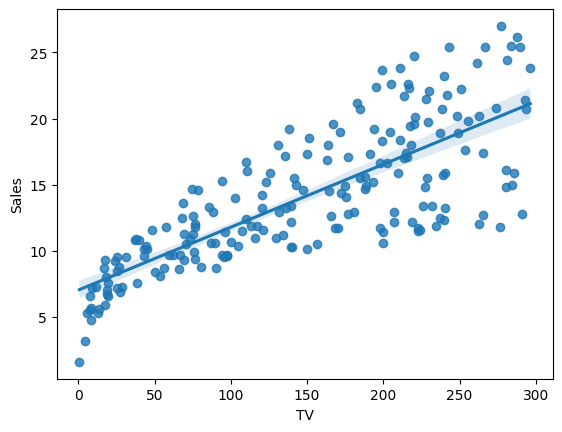

In [115]:
sns.regplot(data=df,x='TV',y='Sales')

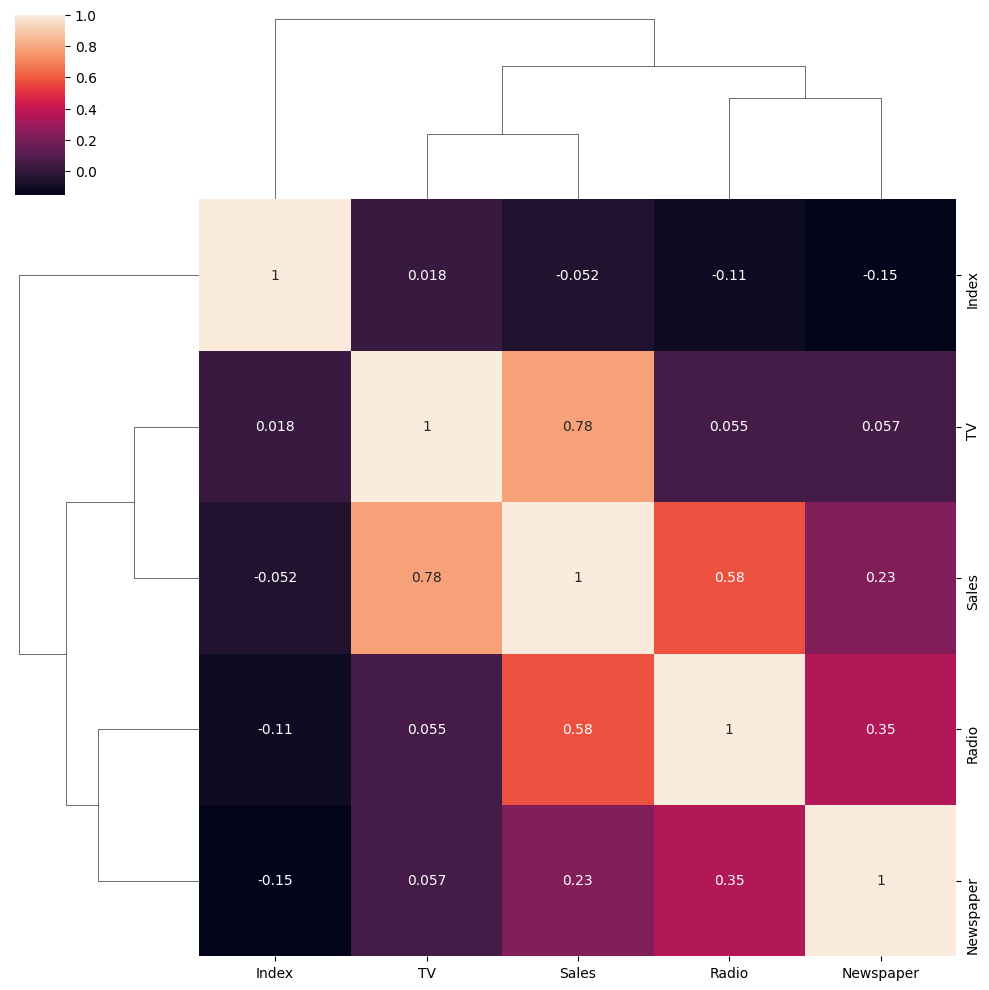

In [116]:
sns.clustermap(data=df.corr(),annot=True)

<Axes: xlabel='TV', ylabel='Sales'>

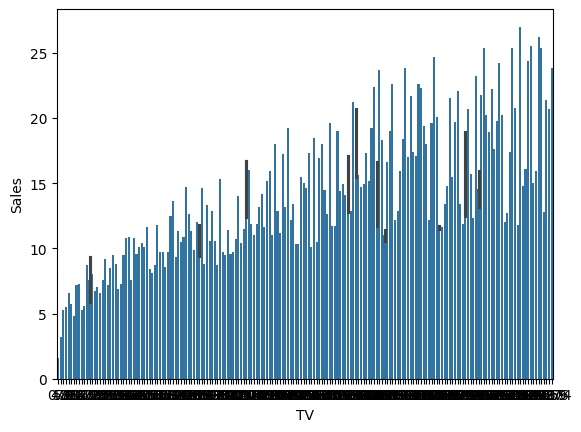

In [117]:
sns.barplot(data=df,x='TV',y='Sales')

<Axes: xlabel='Radio', ylabel='Sales'>

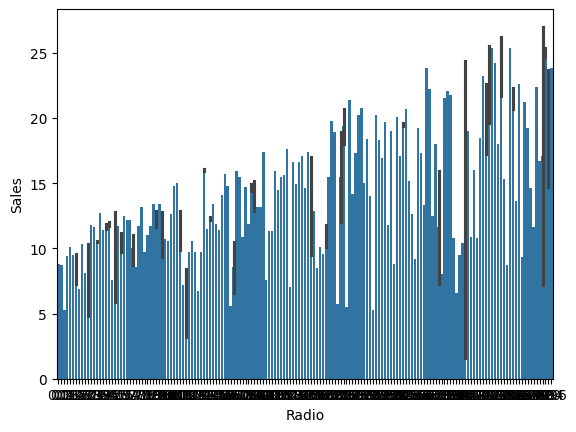

In [118]:

sns.barplot(data=df,x='Radio',y='Sales')

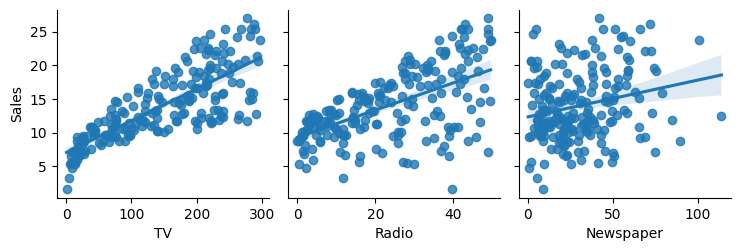

In [119]:
sns.pairplot(df, x_vars=["TV", "Radio", "Newspaper"], y_vars="Sales", kind="reg")


In [120]:
px.scatter_3d(data_frame=df,x='TV',y='Radio',z='Newspaper',color='Sales')

<Axes: >

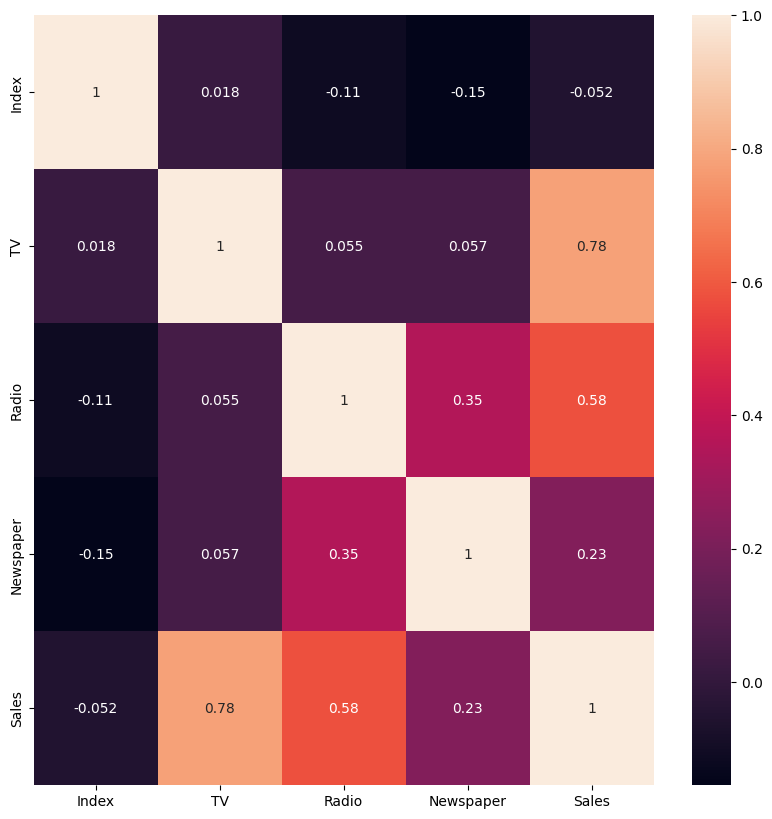

In [121]:
plt.figure(figsize=(10,10))
df_corr = df.select_dtypes(exclude=['object'])
sns.heatmap(df_corr.corr(),annot=True)

## split data

In [122]:
x = df.drop(['Index','Sales'],axis=1)
y = df['Sales']


In [123]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

## scaling

In [124]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

## build models

In [125]:
pip install xgboost

In [126]:
pip install lightgbm

In [127]:
pip install catboost

In [128]:
from sklearn.linear_model import LinearRegression,Lasso,Ridge,ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import VotingRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.tree import ExtraTreeRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [129]:
from math import gamma
models={
    "LinearRegression":LinearRegression(),
    "Lasso":Lasso(alpha=0.1),
    "Ridge":Ridge(alpha=0.1),
    "ElasticNet":ElasticNet(alpha=0.1,l1_ratio=0.5),
    "knn":KNeighborsRegressor(n_neighbors=10,metric="manhattan"),
    "DecisionTreeRegressor":DecisionTreeRegressor(max_depth=10,min_samples_leaf=2,min_samples_split=5),
    "RandomForestRegressor":RandomForestRegressor(n_estimators=50,max_depth=8),
    "SVR":SVR(C=60,gamma=1),
   "GradientBoostingRegressor":GradientBoostingRegressor(n_estimators=30,learning_rate=0.01,max_depth=20),
    "BaggingRegressor":BaggingRegressor(n_estimators=20),
    "AdaBoostRegressor":AdaBoostRegressor(n_estimators=10,learning_rate=0.1),
    "VotingRegressor":VotingRegressor(estimators=[("lr",LinearRegression()),("knn",KNeighborsRegressor())]),
    "StackingRegressor":StackingRegressor(estimators=[("lr",LinearRegression()),("knn",KNeighborsRegressor()),("dt",DecisionTreeRegressor()),("ba",BaggingRegressor()),("et",ExtraTreeRegressor())]),
    "ExtraTreeRegressor":ExtraTreeRegressor(max_depth=5,min_samples_leaf=2,min_samples_split=5),
    "LGBMRegressor":LGBMRegressor(n_estimators=100,learning_rate=0.1,max_depth=20),
    "HistGradientBoostingRegressor":HistGradientBoostingRegressor(max_iter=50,max_depth=5),
    "ExtraTreesRegressor":ExtraTreesRegressor(n_estimators=60,max_depth=10),
    "XGBRegressor":XGBRegressor(n_estimators=100,learning_rate=0.1,max_depth=20)
}

In [130]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.model_selection import cross_val_score
accuracy=[]
for model_name , model in models.items():
    cv_r2_scores = cross_val_score(model, x_train, y_train, cv=5, scoring='r2', n_jobs=-1)
    model.fit(x_train,y_train)
    y_pre_train=model.predict(x_train)
    y_pre_test=model.predict(x_test)
    accuracy.append({
        "model":model_name,
        "MSE_train":mean_squared_error(y_train,y_pre_train),
        "MSE_test":mean_squared_error(y_test,y_pre_test),
        "MAE_train":mean_absolute_error(y_train,y_pre_train),
        "MAE_test":mean_absolute_error(y_test,y_pre_test),
        "R2_train":r2_score(y_train,y_pre_train),
        "R2_test":r2_score(y_test,y_pre_test)
    })

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000040 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 159
[LightGBM] [Info] Number of data points in the train set: 160, number of used features: 3
[LightGBM] [Info] Start training from score 14.100000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMRegressor was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMRegressor was fitted with feature names



In [131]:
pd.DataFrame(accuracy).sort_values(by="R2_test",ascending=False)

,model,MSE_train,MSE_test,MAE_train,MAE_test,R2_train,R2_test
16,ExtraTreesRegressor,0.002804,0.362677,0.040364,0.445598,0.999892,0.988510
6,RandomForestRegressor,0.096928,0.438840,0.219231,0.552002,0.996263,0.986097
12,StackingRegressor,0.146037,0.447363,0.287737,0.552961,0.994369,0.985827
9,BaggingRegressor,0.103234,0.565405,0.228250,0.625750,0.996020,0.982087
17,XGBRegressor,0.000071,0.787144,0.002968,0.679739,0.999997,0.975062
14,LGBMRegressor,0.459031,0.797032,0.421090,0.633914,0.982302,0.974748
15,HistGradientBoostingRegressor,0.632315,0.880714,0.492962,0.701639,0.975620,0.972097
7,SVR,0.036774,1.193810,0.121151,0.815757,0.998582,0.962178
11,VotingRegressor,1.284450,1.918865,0.770334,1.078064,0.950477,0.939206
4,knn,1.717814,2.340345,0.810500,1.094500,0.933768,0.925853


In [132]:
import joblib


In [133]:
joblib.dump(model,"extra_tree_model.pkl")

['extra_tree_model.pkl']

In [134]:
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']